#  Analyse des données de taxis

###  Réalisé par :
- Alireza KARBALAY MOHAMMADI  
- Lina LEBLONDET  

###  Enseignant :
- Samson AMOUSSOU  

###  Établissement :
- ESIEE-IT  

---

##  Objectif
L’objectif de ce notebook est d’analyser un jeu de données de trajets de taxis en utilisant Apache Spark (PySpark).

##  Description des données
Le dataset est au format Parquet et contient des informations sur les trajets :
- dates et heures (pickup, dropoff)
- distance et durée
- tarifs (fare, taxes, tips)
- zones géographiques

##  Outils utilisés
- Databricks
- Apache Spark (PySpark)

##  Plan du notebook

1. Chargement des données  
2. Affichage des premières lignes  
3. Analyse du schéma (structure des données)  
4. Sélection des colonnes importantes  
5. Filtrage des données  
6. Gestion des valeurs manquantes  
7. Transformation des données  
8. Calcul de statistiques descriptives  
9. Agrégation des données  
10. Analyse des résultats  
11. Conclusion  

---

##  Chargement des données

Dans cette étape, nous chargeons le fichier de données au format Parquet en utilisant Apache Spark.

Le format Parquet est un format optimisé pour le traitement de grandes données, permettant une lecture rapide et efficace.

Nous utilisons directement l’environnement Databricks, qui intègre déjà une session Spark active.  
Ainsi, il n’est pas nécessaire de créer manuellement une session Spark (contrairement à Jupyter ou Google Colab).

Le fichier est stocké dans l’espace de travail Databricks (Volumes), ce qui permet un accès direct aux données.

In [0]:
df = spark.read.parquet("/Volumes/workspace/default/taxi_project/fhvhv_tripdata_2026-01 (1).parquet")


##  Affichage des données

Dans cette étape, nous affichons le contenu du DataFrame pour avoir un aperçu des données.

Nous utilisons la fonction `display()` propre à Databricks, qui permet une visualisation claire et interactive des données sous forme de tableau (similaire à Excel).  
Elle offre également des fonctionnalités supplémentaires comme le tri, le filtrage et le scroll horizontal.

Contrairement à `show()`, qui affiche les données sous forme de texte brut et limite la largeur des colonnes (truncate), `display()` est plus adaptée pour les datasets larges avec beaucoup de colonnes.

C’est pourquoi, dans ce notebook, nous privilégions `display()` pour une meilleure lisibilité.

In [0]:
display(df)

hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
HV0003,B03404,B03404,2026-01-01T00:50:37.000,2026-01-01T00:52:31.000,2026-01-01T00:54:30.000,2026-01-01T01:13:23.000,262,79,4.3,1133,31.24,0.0,0.75,2.77,2.75,0.0,0.0,21.1,N,N,N,N,N,1.5
HV0003,B03404,B03404,2026-01-01T00:09:12.000,2026-01-01T00:12:17.000,2026-01-01T00:12:39.000,2026-01-01T00:22:42.000,195,52,1.89,604,8.95,0.0,0.22,0.78,0.0,0.0,0.0,9.1,N,N,N,N,N,0.0
HV0003,B03404,B03404,2026-01-01T00:16:16.000,2026-01-01T00:29:33.000,2026-01-01T00:31:34.000,2026-01-01T00:55:21.000,25,181,1.84,1427,24.06,0.0,0.6,2.13,0.0,0.0,2.67,21.94,N,N,N,N,N,0.0
HV0005,B03406,null,2026-01-01T00:08:19.000,2026-01-01T00:09:08.000,2026-01-01T00:09:37.000,2026-01-01T00:22:12.000,141,226,3.307,755,24.91,0.0,0.62,2.21,2.75,0.0,0.0,13.42,N,N,N,N,Y,1.5
HV0005,B03406,null,2026-01-01T00:21:16.000,2026-01-01T00:26:30.000,2026-01-01T00:26:40.000,2026-01-01T00:39:06.000,226,226,2.06,746,17.86,0.0,0.45,1.59,0.0,0.0,2.98,11.39,N,N,N,N,Y,0.0
HV0005,B03406,null,2026-01-01T00:39:02.000,2026-01-01T00:45:17.000,2026-01-01T00:45:34.000,2026-01-01T00:52:20.000,260,82,1.42,406,18.79,0.0,0.47,1.67,0.0,0.0,0.0,10.66,N,N,N,N,Y,0.0
HV0005,B03406,null,2026-01-01T00:36:04.000,2026-01-01T00:55:27.000,2026-01-01T00:56:27.000,2026-01-01T01:07:09.000,82,95,1.631,642,17.91,0.0,0.45,1.59,0.0,0.0,0.0,15.58,N,N,N,N,Y,0.0
HV0005,B03406,null,2026-01-01T00:20:23.000,2026-01-01T00:24:27.000,2026-01-01T00:25:27.000,2026-01-01T01:04:37.000,144,246,3.883,2350,27.56,0.0,0.69,2.45,2.75,0.0,0.0,30.69,N,N,N,N,N,1.5
HV0003,B03404,B03404,2026-01-01T00:29:54.000,2026-01-01T00:36:04.000,2026-01-01T00:36:32.000,2026-01-01T01:02:28.000,162,113,2.84,1556,29.93,0.0,0.72,2.7,2.75,0.0,0.0,20.9,N,N,N,N,N,1.5
HV0005,B03406,null,2026-01-01T00:45:36.000,2026-01-01T00:53:32.000,2026-01-01T00:54:32.000,2026-01-01T01:43:28.000,148,265,24.381,2936,164.74,16.05,4.52,0.0,0.0,0.0,0.0,87.54,N,N,N,N,N,1.5


##  Structure des données (Schema)

Dans cette étape, nous examinons la structure du DataFrame à l’aide de la fonction `printSchema()`.

Cette fonction permet d’afficher :
- les noms des colonnes  
- le type de données de chaque colonne (string, integer, double, etc.)  
- si les valeurs peuvent être nulles (nullable)

Cela est essentiel pour comprendre la nature des données avant toute analyse ou transformation.

Contrairement à `display()` ou `show()`, qui affichent les données elles-mêmes, `printSchema()` donne une vue globale de la structure du dataset.

In [0]:
df.printSchema()

root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- on_scene_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nullable = true)
 |-- access_a_

##  Nombre de colonnes

Dans cette étape, nous calculons le nombre total de colonnes dans le DataFrame.

La commande `df.columns` retourne la liste de toutes les colonnes, et la fonction `len()` permet de compter leur nombre.

Cela donne une idée de la dimension du dataset et de sa complexité (nombre de variables à analyser).

In [0]:
len(df.columns)

25

##  Types des colonnes

Dans cette étape, nous examinons les types de données de chaque colonne du DataFrame à l’aide de `df.dtypes`.

Cette commande retourne une liste de couples (nom de colonne, type), ce qui permet d’identifier rapidement la nature des variables.

Cela est utile pour :
- détecter d’éventuelles incohérences de types  
- préparer les transformations nécessaires  
- choisir les méthodes d’analyse appropriées  

Contrairement à `printSchema()`, cette méthode donne une vue plus simple et plus compacte des types de données.

In [0]:
df.dtypes

[('hvfhs_license_num', 'string'),
 ('dispatching_base_num', 'string'),
 ('originating_base_num', 'string'),
 ('request_datetime', 'timestamp_ntz'),
 ('on_scene_datetime', 'timestamp_ntz'),
 ('pickup_datetime', 'timestamp_ntz'),
 ('dropoff_datetime', 'timestamp_ntz'),
 ('PULocationID', 'int'),
 ('DOLocationID', 'int'),
 ('trip_miles', 'double'),
 ('trip_time', 'bigint'),
 ('base_passenger_fare', 'double'),
 ('tolls', 'double'),
 ('bcf', 'double'),
 ('sales_tax', 'double'),
 ('congestion_surcharge', 'double'),
 ('airport_fee', 'double'),
 ('tips', 'double'),
 ('driver_pay', 'double'),
 ('shared_request_flag', 'string'),
 ('shared_match_flag', 'string'),
 ('access_a_ride_flag', 'string'),
 ('wav_request_flag', 'string'),
 ('wav_match_flag', 'string'),
 ('cbd_congestion_fee', 'double')]

##  Sélection des colonnes numériques

Dans cette étape, nous identifions les colonnes contenant des données numériques.

Nous utilisons `df.dtypes` pour parcourir les colonnes et leurs types, puis nous filtrons uniquement celles dont le type est numérique (`int`, `double`, `float`, `bigint`).

Cela permet de :
- cibler les variables utiles pour les calculs et les analyses statistiques  
- préparer les étapes suivantes comme les agrégations ou les visualisations  

Cette sélection est particulièrement importante dans les datasets complexes avec de nombreuses colonnes.

In [0]:
[c for c, t in df.dtypes if t in ('int', 'double', 'float', 'bigint')]

['PULocationID',
 'DOLocationID',
 'trip_miles',
 'trip_time',
 'base_passenger_fare',
 'tolls',
 'bcf',
 'sales_tax',
 'congestion_surcharge',
 'airport_fee',
 'tips',
 'driver_pay',
 'cbd_congestion_fee']

##  Sélection des colonnes de type texte

Dans cette étape, nous identifions les colonnes contenant des données de type texte (`string`).

Nous parcourons les colonnes et leurs types à l’aide de `df.dtypes`, puis nous filtrons uniquement celles dont le type est `string`.

Cela permet de :
- repérer les variables qualitatives (catégorielles)  
- préparer des analyses spécifiques comme le groupement ou le nettoyage de texte  
- mieux comprendre la structure globale du dataset  

Les colonnes de type texte sont souvent utilisées pour les identifiants, les catégories ou les zones géographiques.

In [0]:
[(c,t) for c, t in df.dtypes if t in ('string')]

[('hvfhs_license_num', 'string'),
 ('dispatching_base_num', 'string'),
 ('originating_base_num', 'string'),
 ('shared_request_flag', 'string'),
 ('shared_match_flag', 'string'),
 ('access_a_ride_flag', 'string'),
 ('wav_request_flag', 'string'),
 ('wav_match_flag', 'string')]

##   2. Analyse exploratoire des données

Dans cette partie, nous réalisons une première analyse exploratoire du dataset.

L’objectif est de comprendre les principales caractéristiques des trajets à travers quelques indicateurs simples, comme les statistiques descriptives, la distance et le prix des courses.

### Calcul de la distance moyenne

Dans cette étape, nous calculons la distance moyenne des trajets.

Pour cela, nous utilisons la fonction `avg()` de PySpark, appliquée à la colonne `trip_miles`, qui représente la distance des trajets.

Cela permet de répondre à la question : quelle est la distance moyenne parcourue par les taxis ?

In [0]:
from pyspark.sql.functions import avg
df.select(avg("trip_miles")).show()

+-----------------+
|  avg(trip_miles)|
+-----------------+
|4.637686783993771|
+-----------------+



###  Calcul du prix moyen des courses

Dans cette étape, nous calculons le prix moyen des trajets.

Nous utilisons la fonction `avg()` appliquée à la colonne `base_passenger_fare`, qui correspond au tarif de base payé par le passager.

Cela permet de répondre à la question : quel est le prix moyen des courses ?

In [0]:
from pyspark.sql.functions import avg
df.select(avg("base_passenger_fare")).show()

+------------------------+
|avg(base_passenger_fare)|
+------------------------+
|      25.651054501751222|
+------------------------+



###  Distance maximale des trajets

Dans cette étape, nous recherchons la valeur maximale observée pour la distance des trajets.

Nous utilisons la fonction `max()` sur la colonne `trip_miles`, afin d’identifier le trajet le plus long dans le dataset.

Cela permet de répondre à la question : quelle est la distance maximale observée ?

In [0]:
from pyspark.sql.functions import max , min , col
df.select(max("trip_time")).show()


+--------------+
|max(trip_time)|
+--------------+
|         44998|
+--------------+



###  Distance maximale des trajets

Dans cette étape, nous calculons uniquement la distance maximale observée dans le dataset.

Nous utilisons la fonction `max()` sur la colonne `trip_miles` pour identifier le trajet le plus long.

In [0]:
df.select( max("trip_miles")).show()

+---------------+
|max(trip_miles)|
+---------------+
|        1454.43|
+---------------+



## 3.  Analyse de la qualité des données

Dans cette partie, nous évaluons la qualité du dataset en identifiant d’éventuelles anomalies, telles que les valeurs manquantes, les doublons et les incohérences.

L’objectif est de détecter les données incorrectes ou aberrantes avant de poursuivre l’analyse.

###  Détection des valeurs manquantes

Dans cette étape, nous recherchons les valeurs manquantes dans chaque colonne du dataset.

Nous vérifions pour chaque colonne si des valeurs nulles (`null`) existent, puis nous les comptons.

Cela permet d’identifier rapidement les colonnes contenant des données incomplètes.

In [0]:
from pyspark.sql.functions import col, sum

display(
    df.select([
        sum(col(c).isNull().cast("int")).alias(c) for c in df.columns
    ])
)

hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,0,5676843,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


###  Détection des distances irréalistes

Dans cette étape, nous identifions les trajets présentant des distances incohérentes.

Nous considérons comme anomalies :
- les distances nulles ou négatives  
- les distances extrêmement élevées (supérieures à 100 miles)

Nous filtrons ces observations afin de compter combien de trajets sont considérés comme aberrants.

In [0]:
df.filter((df.trip_miles <= 0) | (df.trip_miles > 100)).count()

4409

###  Réponse

 il existe des distances irréalistes dans le dataset.

## 4.  Nettoyage des données

Dans cette partie, nous appliquons différentes opérations de nettoyage afin d’améliorer la qualité du dataset.

Nous supprimons les valeurs incohérentes ou erronées (comme les distances ou prix invalides) ainsi que les éventuels doublons, afin de garantir des analyses fiables.

###  Suppression des distances invalides

Dans cette étape, nous supprimons les trajets dont la distance est inférieure ou égale à 0.

Ces valeurs sont considérées comme incohérentes pour un trajet réel, et peuvent fausser les résultats des analyses.

Nous choisissons donc de les exclure du dataset afin d’améliorer la fiabilité des données.

In [0]:
df = df.filter(df.trip_miles > 0)
df.filter(df.trip_miles <=0).count()

0

###  Suppression des prix invalides

Dans cette étape, nous supprimons les trajets dont le prix est inférieur ou égal à 0.

Un prix nul ou négatif est incohérent pour une course de taxi et peut indiquer une erreur dans les données.

Nous excluons donc ces observations afin d’assurer la qualité et la cohérence du dataset.

In [0]:
df = df.filter(df.base_passenger_fare > 0)
df.filter(df.base_passenger_fare <0).count()

0

### Suppression des doublons

Dans cette étape, nous supprimons les lignes dupliquées dans le dataset.

Les doublons peuvent fausser les résultats des analyses (par exemple en comptant plusieurs fois le même trajet).  
Nous les éliminons donc afin de garantir des résultats plus fiables.

In [0]:
df=df.drop_duplicates()

df.count() - df.dropDuplicates().count()

0

## 5.  Feature engineering

Dans cette partie, nous créons de nouvelles variables à partir des données existantes.

L’objectif est d’enrichir le dataset afin de faciliter l’analyse et d’extraire des informations plus pertinentes, comme la durée des trajets ou le moment de la journée.

###  Calcul de la durée moyenne des trajets

Dans cette étape, nous calculons la durée moyenne des trajets.

Nous créons d’abord une nouvelle variable représentant la durée du trajet, en faisant la différence entre l’heure de dépose (dropoff) et l’heure de prise en charge (pickup).

Ensuite, nous calculons la moyenne de cette durée.

In [0]:
from pyspark.sql.functions import col , unix_timestamp

df=df.withColumn(
    "duration_minutes",
     (unix_timestamp("dropoff_datetime") - unix_timestamp("pickup_datetime")) / 60
    )
df.select(avg("duration_minutes")).show()

+---------------------+
|avg(duration_minutes)|
+---------------------+
|    18.75969603205417|
+---------------------+



###  Analyse de l’heure avec le plus de trajets

Dans cette étape, nous cherchons à identifier l’heure de la journée où le nombre de trajets est le plus élevé.

Nous regroupons les données par heure (`hour`), puis nous comptons le nombre de trajets pour chaque heure.

Enfin, nous trions les résultats par ordre décroissant afin d’identifier l’heure avec le maximum de trajets.

In [0]:
from pyspark.sql.functions import hour , avg
df=df.withColumn("hour",hour("pickup_datetime"))
df.groupBy("hour").count().orderBy("count", ascending=False).show(1)

+----+-------+
|hour|  count|
+----+-------+
|  18|1266721|
+----+-------+
only showing top 1 row


## 6.  Visualisation des données

Dans cette partie, nous réalisons des visualisations afin de mieux comprendre la distribution et les relations entre les variables du dataset.

Les graphiques permettent d’identifier des tendances, des anomalies et des comportements dans les données.

### Distribution des distances

Dans cette étape, nous visualisons la distribution des distances des trajets.

Ce graphique permet de comprendre comment les distances sont réparties (trajets courts, moyens ou longs) et d’identifier d’éventuelles valeurs aberrantes.

###  Interprétation

La distribution initiale est fortement influencée par quelques valeurs extrêmes (distances très élevées).

Après filtrage des valeurs supérieures à 50 miles, on observe que la majorité des trajets sont de courte distance.

In [0]:
import matplotlib.pyplot as plt

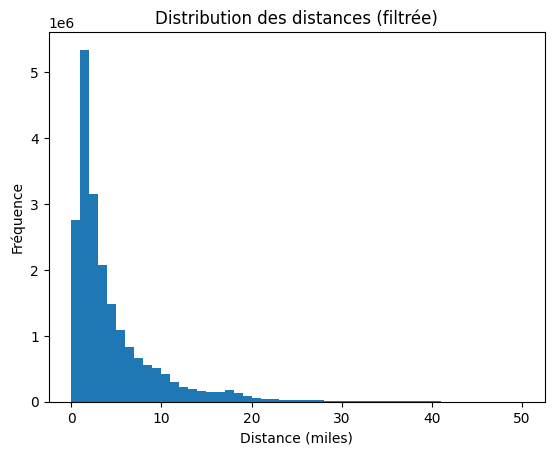

In [0]:
data = df.filter(df.trip_miles < 50).select("trip_miles").toPandas()
plt.hist(data["trip_miles"], bins=50)
plt.xlabel("Distance (miles)")
plt.ylabel("Fréquence")
plt.title("Distribution des distances (filtrée)")
plt.show()

###  Distribution des prix

Dans cette étape, nous visualisons la distribution des prix des trajets.

Ce graphique permet de comprendre comment les tarifs sont répartis et d’identifier d’éventuelles valeurs extrêmes.

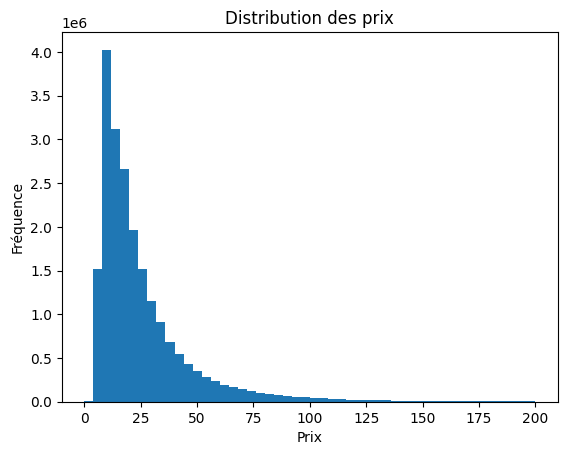

In [0]:
data = df.filter(df.base_passenger_fare < 200).select("base_passenger_fare").toPandas()

plt.hist(data["base_passenger_fare"], bins=50)
plt.xlabel("Prix")
plt.ylabel("Fréquence")
plt.title("Distribution des prix")
plt.show()

###  Nombre de trajets par heure

Dans cette étape, nous analysons le nombre de trajets pour chaque heure de la journée.

Nous regroupons les données par heure (`hour`) puis nous comptons le nombre de trajets afin d’observer les périodes les plus actives.

In [0]:
df.groupBy("hour").count().orderBy("hour").show(24)

+----+-------+
|hour|  count|
+----+-------+
|   0| 729159|
|   1| 515635|
|   2| 386499|
|   3| 312955|
|   4| 321132|
|   5| 377830|
|   6| 582681|
|   7| 885324|
|   8|1086732|
|   9| 990333|
|  10| 893082|
|  11| 866662|
|  12| 896745|
|  13| 944581|
|  14|1023974|
|  15|1056836|
|  16|1097621|
|  17|1217314|
|  18|1266721|
|  19|1224711|
|  20|1132527|
|  21|1066154|
|  22|1034536|
|  23| 927486|
+----+-------+



###  Relation entre distance et prix

Dans cette étape, nous analysons la relation entre la distance des trajets et leur prix.

Étant donné le volume important de données, nous utilisons un échantillon (sample) afin d’améliorer la lisibilité du graphique.

Nous utilisons la bibliothèque Seaborn pour créer un graphique de dispersion (scatter plot), permettant de visualiser la corrélation entre ces deux variables.

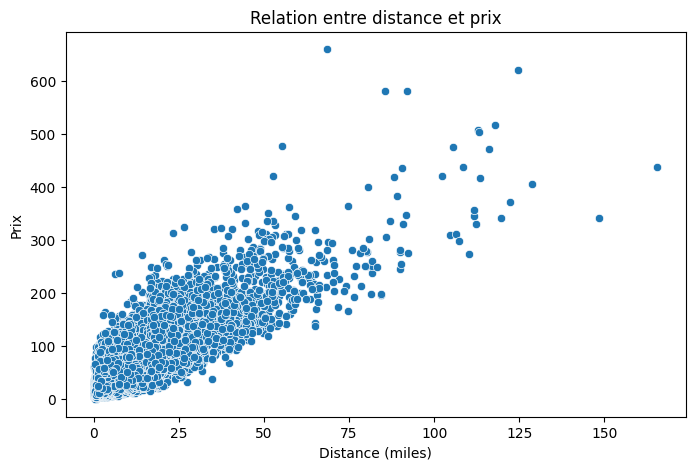

In [0]:
import seaborn as sns


sample_df_comparer = df.select("trip_miles", "base_passenger_fare").sample(0.01).toPandas()
plt.figure(figsize=(8,5))

sns.scatterplot(x=sample_df_comparer["trip_miles"], y=sample_df_comparer["base_passenger_fare"])

plt.title("Relation entre distance et prix")
plt.xlabel("Distance (miles)")
plt.ylabel("Prix")

plt.show()

## 7.  Séparation des données

Dans cette partie, nous séparons les données en deux ensembles : un ensemble d’apprentissage (train set) et un ensemble de test (test set).

Cette séparation permet d’entraîner un modèle sur une partie des données et de l’évaluer sur des données non vues.

%md
###  Pourquoi cette séparation est-elle nécessaire ?

La séparation des données est essentielle pour évaluer la performance d’un modèle de manière fiable.

Le modèle est entraîné sur le train set (80 %) et testé sur le test set (20 %), ce qui permet de vérifier sa capacité à généraliser sur de nouvelles données.

Sans cette séparation, le modèle risquerait de sur-apprendre (overfitting) et de donner des résultats trompeurs.

In [0]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

train_df.count(), test_df.count()

(16670497, 4166733)

## 8.  Entraînement du modèle

Dans cette partie, nous entraînons un modèle de régression linéaire afin de prédire le prix des trajets (`base_passenger_fare`).

Nous utilisons les variables explicatives disponibles pour construire le modèle et analyser l’influence de chaque variable sur le prix.

### Assemblage des variables explicatives

Dans cette étape, nous sélectionnons plusieurs variables explicatives pertinentes pour prédire le prix des trajets.

Nous utilisons `VectorAssembler` pour regrouper ces variables en une seule colonne `features`, qui sera utilisée comme entrée du modèle.

Les variables choisies sont : la distance, la durée, l’heure et le nombre de passagers.

In [0]:
from pyspark.ml.feature import VectorAssembler

features = ["trip_miles", "trip_time", "hour"]

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features"
)

df_model = assembler.transform(df)
df_model.select("features", "base_passenger_fare").show(5)

+------------------+-------------------+
|          features|base_passenger_fare|
+------------------+-------------------+
|[3.84,1455.0,13.0]|              22.01|
| [0.68,442.0,13.0]|              13.05|
| [3.91,848.0,13.0]|              17.76|
|[8.27,2128.0,13.0]|              51.56|
| [1.13,429.0,13.0]|               7.14|
+------------------+-------------------+
only showing top 5 rows


###  Entraînement du modèle de régression linéaire

Dans cette étape, nous entraînons un modèle de régression linéaire afin de prédire le prix des trajets (`base_passenger_fare`).

Le modèle utilise la colonne `features` comme variables explicatives et apprend la relation entre ces variables et le prix.

In [0]:
from pyspark.ml.regression import LinearRegression


train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)
lr = LinearRegression(
    featuresCol="features",
    labelCol="base_passenger_fare"
)

model = lr.fit(train_df)

###  Affichage des coefficients du modèle

Dans cette étape, nous affichons les coefficients du modèle de régression linéaire.

Ces coefficients permettent de comprendre l’influence de chaque variable explicative sur le prix des trajets.

Plus le coefficient est élevé, plus la variable a un impact important sur le prix.

In [0]:
coefs = model.coefficients

print("trip_miles :", coefs[0])
print("trip_time :", coefs[1])
print("hour :", coefs[2])

trip_miles : 2.455871909557635
trip_time : 0.010649965992565617
hour : 0.004563946145775924


###  Réponses

1. Les variables qui influencent le plus le prix d’une course sont celles ayant les coefficients les plus élevés dans le modèle.  
On observe que la distance (`trip_miles`) a l’impact le plus important, suivie par la durée du trajet (`trip_time`).  
L’heure (`hour`) a une influence plus faible.

2. Oui, la distance est la variable la plus importante.  
Cela est cohérent, car plus un trajet est long, plus le prix de la course est élevé.

## 9.  Ajustement des hyperparamètres

Dans cette partie, nous optimisons le modèle en ajustant ses hyperparamètres à l’aide de la validation croisée.

L’objectif est d’améliorer la performance du modèle tout en évitant le sur-apprentissage.

###  Validation croisée et ajustement des hyperparamètres

Dans cette étape, nous utilisons la validation croisée pour optimiser deux hyperparamètres : `regParam` et `elasticNetParam`.

Le paramètre `regParam` contrôle la régularisation, tandis que `elasticNetParam` permet de combiner les régularisations L1 et L2.

Cela permet d’améliorer la performance du modèle et de limiter le sur-apprentissage.

In [0]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="base_passenger_fare",
    predictionCol="prediction",
    metricName="rmse"
)

reg_params = [0.01, 0.1, 1.0]
elastic_params = [0.0, 0.5, 1.0]

results = []

for r in reg_params:
    for e in elastic_params:
        lr = LinearRegression(
            featuresCol="features",
            labelCol="base_passenger_fare",
            regParam=r,
            elasticNetParam=e
        )
        
        model = lr.fit(train_df)
        predictions = model.transform(test_df)
        rmse = evaluator.evaluate(predictions)
        
        results.append((r, e, rmse))

results

[(0.01, 0.0, 11.896837269734286),
 (0.01, 0.5, 11.904360557027438),
 (0.01, 1.0, 11.904377560597624),
 (0.1, 0.0, 11.682815380769986),
 (0.1, 0.5, 11.685908332281047),
 (0.1, 1.0, 11.686069192994548),
 (1.0, 0.0, 11.706613822053345),
 (1.0, 0.5, 11.719769137193595),
 (1.0, 1.0, 11.741604220994642)]

## 10.  Évaluation du modèle

Dans cette partie, nous évaluons la performance du modèle de régression à l’aide de plusieurs métriques : RMSE, MAE et R².

Ces indicateurs permettent de mesurer la qualité des prédictions du modèle.

### Calcul des métriques d’évaluation

Nous utilisons différentes métriques pour évaluer les performances du modèle :

- RMSE : erreur quadratique moyenne  
- MAE : erreur absolue moyenne  
- R² : coefficient de détermination

In [0]:
from pyspark.ml.evaluation import RegressionEvaluator

predictions = model.transform(test_df)

evaluator_rmse = RegressionEvaluator(
    labelCol="base_passenger_fare",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_mae = RegressionEvaluator(
    labelCol="base_passenger_fare",
    predictionCol="prediction",
    metricName="mae"
)

evaluator_r2 = RegressionEvaluator(
    labelCol="base_passenger_fare",
    predictionCol="prediction",
    metricName="r2"
)

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print("RMS:",rmse,"MAE:", mae,"R:", r2)

RMS: 11.741604220994642 MAE: 6.548307639076924 R: 0.7610993403055886


###  Réponses

1. Le modèle est globalement performant, avec des valeurs de RMSE et MAE relativement faibles, et un R² élevé indiquant une bonne capacité d’explication.

2. L’erreur moyenne de prédiction est donnée par la métrique MAE, qui est de XXX.

%md
## 11.  Visualisation des prédictions

Dans cette partie, nous comparons les valeurs réelles et les valeurs prédites par le modèle.

Cette visualisation permet d’évaluer la qualité des prédictions et de vérifier si le modèle est performant.

###  Valeurs réelles vs valeurs prédites

Nous représentons graphiquement les valeurs réelles (`base_passenger_fare`) en fonction des valeurs prédites (`prediction`).

Si le modèle est performant, les points doivent être proches de la diagonale.

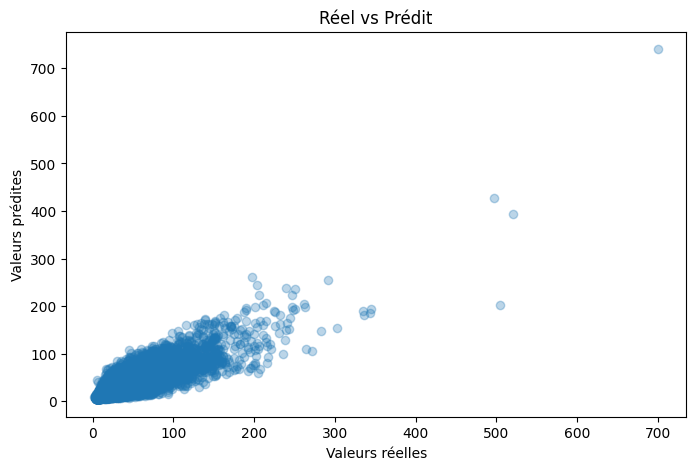

In [0]:
import matplotlib.pyplot as plt

data = predictions.select("base_passenger_fare", "prediction").sample(0.01).toPandas()

plt.figure(figsize=(8,5))

plt.scatter(
    data["base_passenger_fare"],
    data["prediction"],
    alpha=0.3
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit")

plt.show()

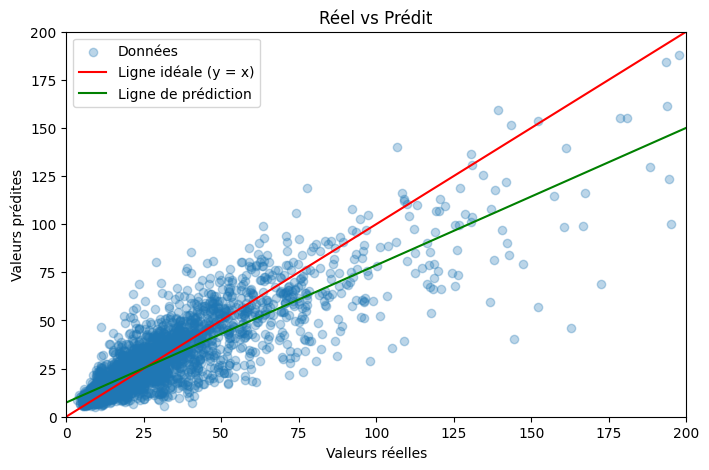

In [0]:
import matplotlib.pyplot as plt
import numpy as np

data = predictions.select("base_passenger_fare", "prediction") \
                  .sample(fraction=0.001) \
                  .toPandas()

plt.figure(figsize=(8,5))


plt.scatter(
    data["base_passenger_fare"],
    data["prediction"],
    alpha=0.3,
    label="Données"
)

x = np.linspace(0, 200, 100)
plt.plot(x, x, color="red", label="Ligne idéale (y = x)")

z = np.polyfit(data["base_passenger_fare"], data["prediction"], 1)
p = np.poly1d(z)
plt.plot(x, p(x), color="green", label="Ligne de prédiction")

plt.xlim(0, 200)
plt.ylim(0, 200)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit")

plt.legend()
plt.show()

### Interprétation

Le graphique compare les valeurs réelles et les valeurs prédites.

La ligne rouge représente le cas idéal où les prédictions sont parfaites.

La ligne verte correspond aux prédictions du modèle.  
On observe que cette ligne est proche de la ligne idéale, ce qui indique que le modèle est globalement performant.

Cependant, une certaine dispersion des points reste visible, indiquant des erreurs de prédiction.